# Linear Regression Theory

## Overview

Suppose we would like to predict a quantitative response $Y$ by observing quantitative predictors $X_1, X_2, \dots, X_p$. A simple way would be to use a linear model of the form

$$Y = \beta_1 X_1 + \dots + \beta_p X_p$$

where $\beta_1, \beta_2, \dots, \beta_p$ are constant parameters to be determined. If we want to include an intercept term, we can just include the constant predictor variable $X_p = 1$. To find out what these coefficients are, we can collect many observations of $(Y, X_1, X_2, \dots, X_p)$, and calculate the best fitting coefficients.

Suppose we collect $n$ such observations, the $i$-th observation will be denoted $(y_i, x_{i1}, x_{i2}, \dots, x_{ip})$. For a more compact notation, the $p$ predictors can be abbreviated by a $p$-dimensional vector $x_i$, so the $i$-th observation can be written as $(y_i, x_i)$. 

We can represent all $n$ sets of observations of predictors using an $n\times p$ matrix $\mathbf{X}$, where each set of observations is written as a row, and the $p$ columns represent the $p$ predictor variables. 

The $n$ observations of responses, in the same order, can be represented by an $n$-dimensional vector $\mathbf{y}$. 

The $p$ coefficients $\beta_1, \beta_2, \dots, \beta_p$ can also be represented by a $p$-dimensional vector $\beta$.

Then our linear model can be expressed in the form
$$ y = x^T \beta$$
for any observation of $x = (x_1, x_2, \dots, x_p)^T$

## Ordinary Least Squares

With our data matrix $\mathbf{X}$ (also called the design matrix) and response vector $\mathbf{y}$, to calculate the values of $\beta$, we need a notion of "best fit". For any choice $\hat{\beta}$ of $\beta$, computing the fitted values $\hat{y}_1, \hat{y}_2, \dots, \hat{y}_n$ given the observed data $x_1, x_2, \dots, x_n$ using our linear model $\hat{y} = x^T \hat{\beta}$ will inevitably lead to errors $(y_1 - \hat{y}_1), (y_2 - \hat{y}_2), \dots, (y_n - \hat{y}_n)$.

In the method of Ordinary Least Squares (OLS), as the name suggests, the "fit" of the observed data to our model is quantified by taking squared errors. The smaller the sum of all $n$ squared errors, the better the fit. We call the sum of squared errors the Residual Sum of Squares (RSS), since the errors $(y_1 - \hat{y}_1), \dots, (y_n - \hat{y}_n)$ are called residuals.

$$\text{RSS} = \sum_{i=1}^{n}{(y_i - \hat{y}_i)^2} = \sum_{i=1}^{n}{(y_i - x_i^T \hat{\beta})^2}$$

In an OLS fit, the coefficients $\beta$ are calculated to minimise $\text{RSS}$, given the design matrix $\mathbf{X}$ and response vector $\mathbf{y}$. We can write $\text{RSS}$ even more compactly as such

$$\text{RSS} = \lVert{\mathbf{y} - \mathbf{X}\beta}\rVert^2 $$

To find the value of $\beta$ that minimises $\text{RSS}$, we can write $\text{RSS}$ in a quadratic form with respect to $\beta$:

$$\text{RSS} = \lVert{\mathbf{y} - \mathbf{X}\beta}\rVert^2 = (\mathbf{y} - \mathbf{X}\beta)^T(\mathbf{y} - \mathbf{X}\beta) = \beta^T\mathbf{X}^T\mathbf{X}\beta - 2\beta^T(\mathbf{X}^T \mathbf{y}) + \mathbf{y}^T \mathbf{y}$$

and arrive at the OLS-fitted coefficients vector

$$\hat{\beta} = (\mathbf{X}^T \mathbf{X})^{-1}\mathbf{X}^T \mathbf{y}$$

The vector of fitted values $\hat{y}_i = x_i^T \hat{\beta}$ will then be

$$\hat{\mathbf{y}} = \mathbf{X}\hat{\beta} = \mathbf{X}(\mathbf{X}^T \mathbf{X})^{-1}\mathbf{X}^T \mathbf{y} = \mathbf{H} \mathbf{y}$$

where $\mathbf{H} = \mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T$ is called the projection matrix, for reasons we will get to soon.

The vector of residuals $\hat{e}_i = y_i - \hat{y}_i$ will be

$$\hat{\mathbf{e}} = \mathbf{y} - \hat{\mathbf{y}} = (\mathbf{I} - \mathbf{H})\mathbf{y}$$

Using the above theory, we can fit our own OLS linear model:

In [92]:
import numpy as np

np.set_printoptions(precision=3, suppress=True, sign=' ')

rng = np.random.default_rng(seed=1)

X = rng.random((10, 3))                     # Data matrix
beta = rng.random(3)                        # True coefficients
y = X @ beta + rng.normal(0, 0.2, size=10)  # Observed responses with IID Gaussian errors

print(f'Data matrix:\n{X}')
print(f'Response vector:   {y}')
print(f'True coefficients: {beta}')

print(f'\nOLS Results:\n')

beta_hat = np.linalg.inv(X.T @ X) @ X.T @ y # OLS-fitted coefficients
y_hat = X @ beta_hat                        # OLS-fitted responses
e_hat = y - y_hat                           # Residuals of fit

print(f'Fitted coefficients: {beta_hat}')
print(f'Fitted responses:    {y_hat}')
print(f'Residuals:           {e_hat}')
print(f'RSS:                 {np.linalg.norm(e_hat) ** 2:.3f}')

Data matrix:
[[ 0.512  0.95   0.144]
 [ 0.949  0.312  0.423]
 [ 0.828  0.409  0.55 ]
 [ 0.028  0.754  0.538]
 [ 0.33   0.788  0.303]
 [ 0.453  0.134  0.403]
 [ 0.203  0.262  0.75 ]
 [ 0.28   0.485  0.981]
 [ 0.962  0.725  0.541]
 [ 0.277  0.161  0.97 ]]
Response vector:   [ 0.389  1.198  0.947  0.57   0.348  0.171  0.637  0.834  0.672  0.63 ]
True coefficients: [ 0.516  0.116  0.623]

OLS Results:

Fitted coefficients: [ 0.585  0.054  0.598]
Fitted responses:    [ 0.437  0.825  0.835  0.378  0.417  0.514  0.582  0.777  0.925  0.751]
Residuals:           [-0.048  0.373  0.112  0.191 -0.069 -0.342  0.055  0.058 -0.253 -0.121]
RSS:                 0.398


A much simpler way would be to use `statsmodels` or `sklearn`:

In [93]:
import statsmodels.api as sm

OLS_model = sm.OLS(y, X).fit()

print(f'Fitted coefficients: {OLS_model.params}')
print(f'Fitted responses:    {OLS_model.fittedvalues}')
print(f'Residuals:           {OLS_model.resid}')
print(f'RSS:                 {OLS_model.ssr:.3f}')

Fitted coefficients: [ 0.585  0.054  0.598]
Fitted responses:    [ 0.437  0.825  0.835  0.378  0.417  0.514  0.582  0.777  0.925  0.751]
Residuals:           [-0.048  0.373  0.112  0.191 -0.069 -0.342  0.055  0.058 -0.253 -0.121]
RSS:                 0.398


## Geometrical Interpretation

Consider a $n$-dimensional vector space $\mathbb{R}^n$. For each variable $X_1, X_2, \dots, X_p, Y$, the $n$ observations can be formed into a $n$-dimensional vector corresponding to that variable. We end up with $p$ vectors $\mathbf{x}_1, \mathbf{x}_2, \dots, \mathbf{x}_p$ for the observations of variables $X_1, X_2, \dots, X_p$ and one vector $\mathbf{y}$ for the observations of variable $Y$.

Finding a linear fit to our data $(\mathbf{y}, \mathbf{X})$ of the form $Y=\beta_1 X_1 + \dots + \beta_p X_p$ is mathematically identical to finding a linear combination of $\mathbf{x}_1, \mathbf{x}_2, \dots, \mathbf{x}_p$ that gives a resultant $n$-dimensional vector closest to $\mathbf{y}$.

When we apply the method of OLS, the number of predictor variables $p$ must be smaller than the number of sets of observations $n$. In this case, many points in the $n$-dimensional vector space cannot be expressed exactly as a linear combination of the $\mathbf{x}_i$'s. For this reason, we can only hope to get a linear combination closest to $\mathbf{y}$ but not exactly equal to $\mathbf{y}$.

Geometrically, the most intuitive notion of distance would be the Euclidean distance. For any two $n$-dimensional vectors $\mathbf{a}=(a_1, a_2, \dots, a_n)^T, \mathbf{b}=(b_1, b_2, \dots, b_n)^T$, their Euclidean distance is defined by

$$\lVert{\mathbf{a}-\mathbf{b}}\rVert = \sqrt{(a_1 - b_1)^2 + \dots + (a_n - b_n)^2}$$

in a manner reminiscent of the Pythagoras' theorem. The $\text{RSS}$ metric used to quantify fit is exactly equal to the square of 

$$\lVert{\mathbf{y} - (\beta_1 \mathbf{x}_1 + \dots + \beta_p \mathbf{x}_p)}\rVert$$

so minimising $\text{RSS}$ is equivalent to finding a linear combination of the $\mathbf{x}_i$'s with the closest Euclidean distance to $\mathbf{y}$. 

This linear combination would therefore have to be the foot of perpendicular from the point $\mathbf{y}$ onto the $p$-dimensional subspace spanned by the vectors $\mathbf{x}_1, \mathbf{x}_2, \dots, \mathbf{x}_p$.

![Projection from yhat onto span(X)](visuals/y-yhat-ehat.gif)

Recall that earlier we already solved for a closed form for the linear combination, in terms of a "projection matrix" $\mathbf{H}$:

$$\beta_1 \mathbf{x}_1 + \dots + \beta_p \mathbf{x}_p = \hat{\mathbf{y}} = \mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T \mathbf{y} = \mathbf{H} \mathbf{y}$$

Now we know that the geometrical significance of $\mathbf{H}$ is that it represents a perpendicular projection onto the subspace spanned by the columns $\mathbf{x}_1, \dots, \mathbf{x}_p$ of $\mathbf{X}$, hence the name "projection matrix". 

For this reason, $\mathbf{H}$ has the property that $\mathbf{H}^2 = \mathbf{H}$ (idempotency). Intuitively this makes sense, as after projecting down onto the subspace spanned by the columns of $\mathbf{X}$, projecting the resultant vector again would do nothing since it already lies in the subspace.

## Successive Orthogonalisation

The geometrical interpretation of OLS fitting motivates another way to find $\hat{\beta}$ and $\hat{\mathbf{y}}$. We can directly try to find the foot of perpendicular from $\mathbf{y}$ onto the subspace spanned by the columns of $\mathbf{X}$.

First, we construct a set of $p$ pairwise orthogonal vectors $\mathbf{w}_1, \dots, \mathbf{w}_p$ which span the same subspace spanned by the columns of $\mathbf{X}$ (i.e. orthogonal basis for $\text{span}(\mathbf{X})$). This can be done using the Gram-Schmidt procedure:

For the first basis vector $\mathbf{w}_1$, we simply let it be $\mathbf{x}_1$

$$\mathbf{w}_1 = \mathbf{x}_1$$

For the second basis vector $\mathbf{w}_2$, we eliminate the component of $\mathbf{x}_2$ parallel to $\mathbf{w}_1$. 

$$\mathbf{w}_2 = \mathbf{x}_2 - \frac{\mathbf{w}_1^T \mathbf{x}_2}{\mathbf{w}_1^T \mathbf{w}_1}\mathbf{w}_1$$

In general, for the $k$-th basis vector $\mathbf{w}_k$, we eliminate the components of $\mathbf{x}_k$ parallel to $\mathbf{w}_1, \mathbf{w}_2, \dots, \mathbf{w}_{k-1}$:

$$\mathbf{w}_k = \mathbf{x}_k - \sum_{i=1}^{k-1}{\frac{\mathbf{w}_i^T\mathbf{x}_k}{\mathbf{w}_i^T \mathbf{w}_i}\mathbf{w}_i}$$

This allows us to express the $k$-th vector $\mathbf{x}_k$ in terms of the first $k$ orthogonal basis vectors $\mathbf{w}_1, \dots, \mathbf{w}_k$.

Then if $\hat{\mathbf{y}}$ is the foot of perpendicular from $\mathbf{y}$ onto the span of $\mathbf{x}_1, \dots, \mathbf{x}_p$, using our orthogonal basis, the component of $\hat{\mathbf{y}}$ parallel to $\mathbf{w}_k$ is simply

$$\frac{\mathbf{w}_k^T \mathbf{y}}{\mathbf{w}_k^T \mathbf{w}_k}\mathbf{w}_k = \frac{\mathbf{w}_k^T \mathbf{y}}{\mathbf{w}_k^T \mathbf{w}_k}\left(\mathbf{x}_k - \sum_{i=1}^{k-1}{\frac{\mathbf{w}_i^T\mathbf{x}_k}{\mathbf{w}_i^T \mathbf{w}_i}\mathbf{w}_i}\right)$$

Therefore, we get

$$\hat{\mathbf{y}} = \sum_{k=1}^{p}{\frac{\mathbf{w}_k^T \mathbf{y}}{\mathbf{w}_k^T \mathbf{w}_k}\mathbf{w}_k} = \sum_{k=1}^{p}{\left[\frac{\mathbf{w}_k^T \mathbf{y}}{\mathbf{w}_k^T \mathbf{w}_k}\left(\mathbf{x}_k - \sum_{i=1}^{k-1}{\frac{\mathbf{w}_i^T\mathbf{x}_k}{\mathbf{w}_i^T \mathbf{w}_i}\mathbf{w}_i}\right)\right]}$$

Notice that in this summation, the term $\mathbf{x}_p$ appears once in the term $\frac{\mathbf{w}_p^T \mathbf{y}}{\mathbf{w}_p^T \mathbf{w}}\mathbf{x}_p$, and all other terms are in terms of $\mathbf{x}_1, \dots, \mathbf{x}_{k-1}, \mathbf{w}_1, \dots, \mathbf{w}_{k-1}$. Since each of $\mathbf{x}_1, \dots, \mathbf{x}_{k-1}$ can be expressed as a linear combination of some of $\mathbf{w}_1, \dots, \mathbf{w}_{k-1}$, all other terms can be expressed as a linear combination of $\mathbf{x}_1, \dots, \mathbf{x}_{k-1}$. This means that the coefficient $\hat{\beta}_p$ of $\mathbf{x}_p$ is precisely equal to $\frac{\mathbf{w}_p^T \mathbf{y}}{\mathbf{w}_p^T \mathbf{w}_p^T}$.

Repeating this orthogonalisation process in a different order of predictor variables, we can get another predictor variable to end up as the last to be orthogonalised, and hence calculate its coefficient. This method allows us to avoid expensive matrix inversion operations.

In addition, a single iteration of this process is sufficient to generate all the fitted values, and hence the residuals.

The code below illustrates that the method of successive orthogonalisation is able to generate the coefficient of the predictor variable represented by the last orthogonalised vector. From the earlier code, we can see that the coefficient of X3 is indeed `0.598`. The fitted values and residuals also agree with the earlier OLS-fitted values.

In [94]:
P = 3       # Number of predictor variables
N = 10      # Number of sets of observations

w = np.zeros((N, P))    # Initialise orthogonal basis vectors, the columns of w are the basis vectors

for i in range(P):      # Gram-Schmidt orthogonalisation algorithm
    w[:,i] = X[:,i]
    for j in range(i):
        w[:,i] -= ((w[:,j] @ X[:,i]) / (w[:,j] @ w[:,j])) * w[:,j]

beta_hat_3 = (w[:,P-1] @ y) / (w[:,P-1] @ w[:,P-1])     # Extracting coefficient of X3
fitted_values = sum(((w[:,j] @ y) / (w[:,j] @ w[:,j])) * w[:,j] for j in range(P)) 

print(f'Coefficient of X3: {beta_hat_3:.3f}')
print(f'Fitted values:     {fitted_values}')
print(f'Residuals:         {y - fitted_values}')

Coefficient of X3: 0.598
Fitted values:     [ 0.437  0.825  0.835  0.378  0.417  0.514  0.582  0.777  0.925  0.751]
Residuals:         [-0.048  0.373  0.112  0.191 -0.069 -0.342  0.055  0.058 -0.253 -0.121]


We can get the coefficients of the other variables by repeating the algorithm with different last-orthogonalised vectors. These values indeed agree with the OLS-fitted coefficients found earlier.

In [95]:
coefficients = np.zeros(P)

# Facilitates cyclic permutation of predictors for different orthogonalisations
predictors = [i for i in range(P)] + [i for i in range(P-1)]

for iteration in range(P):

    sequence = predictors[iteration:iteration + P]      # Sequence of predictors for orthogonalisation
    w = np.zeros((N, P))                                # Initialises basis vectors

    for index, i in enumerate(sequence):    # Gram-Schmidt orthogonalisation
        w[:,i] = X[:,i]
        for j in sequence[:index]:
            w[:,i] -= ((w[:,j] @ X[:,i]) / (w[:,j] @ w[:,j])) * w[:,j]

    predictor = sequence[-1]    # Last variable to be orthogonalised
    coefficients[predictor] = (w[:,predictor] @ y) / (w[:,predictor] @ w[:,predictor])

print(f'Successive Orthogonalisation Coefficients: {coefficients}')

Successive Orthogonalisation Coefficients: [ 0.585  0.054  0.598]


Following the Gram-Schmidt procedure, for each $k$ we were able to express $\mathbf{x}_k$ in terms of $\mathbf{w}_1, \dots, \mathbf{w}_k$:

$$\mathbf{x}_k = \mathbf{w}_k + \sum_{i=1}^{k-1}{\frac{\mathbf{w}_i^T \mathbf{x}_k}{\mathbf{w}_i^T \mathbf{w}_i}\mathbf{w}_i}$$

This means that we can write

$$\mathbf{X} = (\mathbf{x}_1 \mathbf{x}_2 \dots \mathbf{x}_p)= (\mathbf{w}_1 \mathbf{w}_2 \dots \mathbf{w}_p)\mathbf{\Gamma} = \mathbf{W}\mathbf{\Gamma}$$

where $\mathbf{\Gamma}$ is an upper-right triangular $p\times p$ matrix, and $\mathbf{W}$ is a $p\times p$ matrix whose columns are pairwise orthogonal.

In addition, we can normalise our orthogonal basis vectors $\mathbf{w}_1, \dots, \mathbf{w}_p$ to unit vectors: $\mathbf{q}_i = \frac{\mathbf{w}_i}{\lVert\mathbf{w}_i\rVert}$. Then for some $p\times p$ upper-right triangular matrix $\mathbf{R}$ we can write

$$\mathbf{X} = (\mathbf{q}_1 \mathbf{q}_2 \dots \mathbf{q}_p)\mathbf{R} = \mathbf{Q}\mathbf{R}$$

Here, $\mathbf{Q}$ is an orthogonal matrix satisfying $\mathbf{Q}^T\mathbf{Q}=\mathbf{I}$.

Substituting formulae from OLS, we get
$$\hat{\beta} = (\mathbf{X}^T \mathbf{X})^{-1}\mathbf{X}^T \mathbf{y} = (\mathbf{R}^T \mathbf{Q}^T \mathbf{Q} \mathbf{R})^{-1} \mathbf{R}^T \mathbf{Q}^T \mathbf{y} = (\mathbf{R}^T \mathbf{R})^{-1} \mathbf{R}^T \mathbf{Q}^T \mathbf{y} = \mathbf{R}^{-1} \mathbf{Q}^T \mathbf{y}$$

$$\hat{\mathbf{y}} = \mathbf{X}\hat{\beta} = \mathbf{Q}\mathbf{R}\mathbf{R}^{-1}\mathbf{Q}^T \mathbf{y{}} = \mathbf{Q}\mathbf{Q}^T \mathbf{y}$$

Hence, the project matrix can be expressed as $\mathbf{H} = \mathbf{Q}\mathbf{Q}^T$.

## Additional Assumptions on $X$ and $Y$

In order to provide confidence intervals of our predictions, we need to make some assumptions on $Y$. Suppose that the true model is indeed a linear model, with unknown true coefficients $\beta$, so $Y \approx \beta_1 X_1 + \dots + \beta_p X_p$. However in the real world, due to many uncontrollable factors at play, $Y$ follows some normal distribution about the mean $\beta_1 X_1 + \dots + \beta_p X_p$:

$$Y \sim \text{N}(X^T \beta, \sigma^2)$$

Finally, we assume that the conditional distributions of $Y$ given $X$ are independent of each other. Hence, for $n$ fixed observations of the predictors $x_1, x_2, \dots, x_n$, the responses $y_1, y_2, \dots, y_n$ are given by

$$y_i = x_i^T \beta + \varepsilon_i$$

where $\varepsilon_1, \dots, \varepsilon_n$ are independent and identically distributed $\text{N}(0, \sigma^2)$. With these three assumptions:
1. the true relationship between $Y$ and $X$ is linear,
2. the errors in $Y$ are normally distributed with mean $0$ and common variance $\sigma^2$, and
3. the errors in $Y$ are independent of each other

we can then analyse the distributions of our estimates.


## Distributions of Estimates

Since $\hat{\beta} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T \mathbf{y}$ is a linear combination of $\mathbf{y}$, and our three assumptions imply $\mathbf{y} \sim \text{N}(\mathbf{X}\beta, \sigma^2 \mathbf{I})$, then

$$\mathbb{E}[\hat{\beta}] = (\mathbf{X}^T \mathbf{X})^{-1}\mathbf{X}^T \mathbb{E}[\mathbf{y}] =(\mathbf{X}^T \mathbf{X})^{-1}\mathbf{X}^T \mathbb{X} \beta = \beta $$

$$\text{var}(\hat{\beta}) = ((\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T) (\text{var}(\mathbf{y})) ((\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T)^T = \sigma^2(\mathbf{X}^T \mathbf{X})^{-1} $$

This means that

$$\hat{\beta} \sim \text{N}(\beta, \sigma^2 (\mathbf{X}^T \mathbf{X})^{-1})$$

Next, since $\hat{\mathbf{y}} = \mathbf{X}\hat{\beta}$, we get

$$\hat{\mathbf{y}} \sim \text{N}(\mathbf{X}\beta, \sigma^2 \mathbf{X}(\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T) = \text{N}(\mathbf{X}\beta, \sigma^2 \mathbf{H})$$

Finally, since $\hat{\mathbf{e}} = (\mathbf{I} - \mathbf{H})\mathbf{y}$, where $\mathbf{I}, \mathbf{H}$ are both symmetric and both idempotent, and $\mathbf{H}\mathbf{X} = \mathbf{X}$, then

$$\hat{\mathbf{e}} \sim \text{N}((\mathbf{I} - \mathbf{H})\mathbf{X}\beta, (\mathbf{I} - \mathbf{H})(\sigma^2 \mathbf{I})(\mathbf{I} - \mathbf{H})^T) = \text{N}(\mathbf{0}, \sigma^2(\mathbf{I} - \mathbf{H}))$$

## Estimates of $\sigma^2$

In all of the above equations, we had to include $\sigma^2$. However, the true value of the variance $\sigma^2$ is unknown, so we need an estimate $\hat{\sigma}^2$ for it.

We focus our attention on $\text{RSS}$:

$$\text{RSS} = \sum_{i=1}^{n}{(y_i - \hat{y}_i)^2} = \lVert\mathbf{e}\rVert^2 = \mathbf{e}^T \mathbf{e}$$

Since $\mathbf{e} = (\mathbf{I} - \mathbf{H})\mathbf{y}$, and $(\mathbf{I} - \mathbf{H})^T(\mathbf{I}-\mathbf{H}) = \mathbf{I}-\mathbf{H}$ then

$$\mathbf{e}^T \mathbf{e} = \mathbf{y}^T (\mathbf{I} - \mathbf{H}) \mathbf{y} = \mathbf{y}^T \mathbf{y} - \mathbf{y}^T \mathbf{H} \mathbf{y}$$

Recall from successive orthogonalisation, that if $\mathbf{Q}$ is an $n\times p$ matrix whose columns form an orthonormal basis of the subspace spanned by the columns of $\mathbf{X}$, then $\mathbf{H} = \mathbf{Q}\mathbf{Q}^T$, so

$$\mathbf{y}^T \mathbf{y} - \mathbf{y}^T \mathbf{H} \mathbf{y} = \lVert\mathbf{y}\rVert^2 - \lVert{\mathbf{Q}^T \mathbf{y}}\rVert^2$$

To create cancellations, we try to compute $\lVert\mathbf{y}\rVert$ in an orthonormal basis of $\mathbb{R}^n$ containing the column vectors of $\mathbf{Q}$. Let the extended orthonormal basis be

$$(\mathbf{q}_1, \mathbf{q}_2, \dots, \mathbf{q}_p, \mathbf{q}_{p+1}, \dots, \mathbf{q}_n) = (\mathbf{Q} \quad \mathbf{Q'}) = \mathbf{P}$$

Since $\mathbf{P}$ is orthogonal, then $\lVert\mathbf{y}\rVert$ = $\lVert\mathbf{P}^T\mathbf{y}\rVert$, and so

$$\lVert\mathbf{y}\rVert^2 - \lVert\mathbf{Q}^T \mathbf{y}\rVert^2 = \lVert\mathbf{P}^T\mathbf{y}\rVert^2 - \lVert\mathbf{Q}^T\mathbf{y}\rVert^2 = \sum_{i=1}^{n}(\mathbf{q}_i^T \mathbf{y})^2 - \sum_{i=1}^{p}(\mathbf{q}_i^T \mathbf{y})^2 = \sum_{i=p+1}^{n}(\mathbf{q}_i^T \mathbf{y})^2$$

But notice that $\mathbf{q}_i^T\mathbf{y} \sim \text{N}(\mathbf{q}_i^T\mathbf{X}\beta, \mathbf{q}_i^T(\sigma^2 \mathbf{I})\mathbf{q}_i)=\text{N}(\mathbf{q}_i^T\mathbf{Q}\mathbf{R}\beta, \sigma^2)$ since $\mathbf{X}=\mathbf{Q}\mathbf{R}$ and $\mathbf{q}_i^T\mathbf{q}_i = 1$. 

For $i = p+1, p+2, \dots, n$, we must have $\mathbf{q}_i^T \mathbf{Q} = \mathbf{0}^T$ since $\mathbf{q}_i$ are orthogonal to the columns $\mathbf{q}_1, \dots, \mathbf{q}_p$ of $\mathbf{Q}$, so $\mathbf{q}_i^T\mathbf{Q}\mathbf{R}\beta = \mathbf{0}^T\mathbf{R}\beta = 0$, implying

$$\mathbf{q}_i^T\mathbf{y} \sim \text{N}(0, \sigma^2) \quad \quad \forall i = p+1, p+2, \dots, n$$

Therefore, the $\text{RSS}$ has a chi-squared distribution:

$$\text{RSS}=\lVert\mathbf{y}\rVert^2 - \lVert\mathbf{Q}^T\mathbf{y}\rVert^2 = \sum_{i=p+1}^{n}(\mathbf{q}_i^T\mathbf{y})^2 \sim \sigma^2 \chi_{n-p}^2$$

Essentially, $\text{RSS}$ is the sum of squares of the components of $\mathbf{y}$ in the directions orthogonal to the column span of $\mathbf{X}$. Since the mean of $\mathbf{y}$ is a linear combination of $\mathbf{x}_i$'s, these orthogonal components have mean $0$. Summing them will create a chi-squared distribution. Since there are $n-p$ dimensions outside of the column span of $\mathbf{X}$, the chi-squared distribution is $\chi_{n-p}^2$.

As the distribution $\chi_{n-p}^2$ has mean $n-p$, then $\mathbb{E}[\text{RSS}] = (n-p)\sigma^2$, so an unbiased estimate for $\sigma^2$ is

$$\hat{\sigma}^2 = \frac{\text{RSS}}{n-p}$$

To illustrate this chi-squared distribution, we will run a Monte Carlo simulation. Same as before, in each simulation, we will generate $10$ random sets of observations of $3$ predictors (including a constant variable), and use the relationship $Y = X^T\beta + \varepsilon$ to generate the $10$ respective responses. We then fit an OLS regression model and calculate the $\text{RSS}$ for each simulation. We will run $10000$ simulations and finally plot a empirical density histogram.

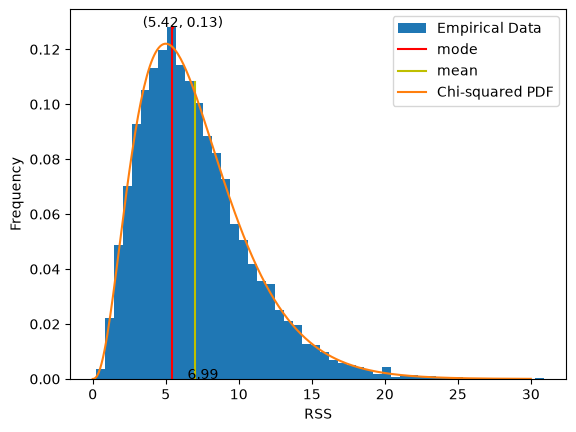

In [96]:
import matplotlib.pyplot as plt
import scipy.stats as stats

N_SIMULATIONS = 10000
N = 10
P = 3

RSS = []
rng_mc = np.random.default_rng(seed=2)

X_fixed = np.hstack([np.ones((N, 1)), rng.normal(loc=0, scale=2, size=(N, P - 1))])
true_beta = np.array([[1.2], [3.0], [-2.1]])
true_sigma2 = 1

hat_matrix = X_fixed @ np.linalg.inv(X_fixed.T @ X_fixed) @ X_fixed.T

for _ in range(N_SIMULATIONS):
    y = X_fixed @ beta + rng.normal(loc=0, scale=true_sigma2, size=N)
    yhat = hat_matrix @ y
    ehat = y - yhat
    rss = np.linalg.norm(ehat) ** 2
    RSS.append(rss)

figure, ax = plt.subplots(1, 1)
counts, bins, patches = ax.hist(RSS, bins=50, label='Empirical Data', density=True)
ax.set_xlabel('RSS')
ax.set_ylabel('Frequency')

maximum_index = np.argmax(counts)
mode_height = counts[maximum_index]
mode = (bins[maximum_index] + bins[maximum_index + 1]) / 2
ax.axvline(x=mode, label='mode', color='r', ymax=mode_height / ax.get_ylim()[1])
ax.scatter([mode], [mode_height], s=2, color='r')
ax.annotate(text=f'({mode:.2f}, {mode_height:.2f})', xy=(mode, mode_height), xytext=(mode - 2, mode_height))
mean = np.mean(RSS)
ax.axvline(x=mean, label='mean', color='y', ymax=mode_height / ax.get_ylim()[1] - 0.15)
ax.annotate(text=f'{mean:.2f}', xy=(mean, 0), xytext=(mean - 0.5, 0))

x = np.linspace(0, 30, 300)
deg_freedom = N - P
chi2_pdf = stats.chi2.pdf(x, df=deg_freedom, scale=true_sigma2)

ax.plot(x, chi2_pdf, label='Chi-squared PDF')
ax.legend()


As we can see, the RSS distribution matches the theoretical $\sigma^2\chi_{n-p}^2$ distribution closely. The mean of our empirical distribution is $6.92$, almost exactly equal to $n-p=7$. The mode is $4.92$, which is quite close to the theoretical mode of $n - p - 2 = 5$.

## Potential Problems

A few inadequacies might arise from a linear regression model. The underlying relationship between predictors and response may not be linear to begin with, resulting in model bias.

If the underlying relationship is close enough to a linear relationship, we may try to use our model to predict future responses given observed predictor values. We making a prediction, we need to quote a confidence interval, often at 95% confidence, and this interval is computed by making the aforementioned assumpitions on the distributions of errors.

Given a data point $x$, the predicted mean response is $\hat{y} = x^T \hat{\beta}$, with distribution
$$\hat{y} \sim \text{N}(x^T \beta, \sigma^2 x^T(\mathbf{X}^T\mathbf{X})^{-1}x)$$

Therefore, the estimated standard error will be
$$\text{s.e.} = \hat{\sigma} \sqrt{x^T (\mathbf{X}^T \mathbf{X}^{-1}) x} = \sqrt{\left(\frac{\text{RSS}}{n-p}\right)x^T (\mathbf{X}^T \mathbf{X})^{-1}x}$$

If any of the assumptions on the error terms (i.e. independent normal distribution with common variance) are not actually true, then the confidence interval would be inaccurate.

Finally, different data points influence the fit by different extents. From the equation
$$\hat{\mathbf{y}} = \mathbf{H}\mathbf{y}$$

we get that the fitted value $\hat{y}_i$ for the $i$-th observation depends on both the actual observed value $y_i$ and the observed values of other data points $y_j$, by

$$\hat{y}_i = \mathbf{H}_{ii}y_i + \sum_{j\neq i}\mathbf{H}_{ij}y_j$$

The value of $\mathbf{H}_{ii}$ is therefore a measure of how much the observed value $y_i$ influences the fitted value $\hat{y}_i$. This quantity is called the "leverage". A data point with high leverage has the potential to greatly skew the fitted model, so it is good to try and identify them, if they exist.

Fortunately, high leverage points will only skew the fitted model if they are themselves outliers. To check if a point is an outlier, we look at its fitted residual.

## Residual Analysis

To check whether the underlying relationship is linear, we can plot the residuals against the response values, making a scatter plot of $(\hat{y}_i, \hat{e}_i)$. If the relationship were truly linear, the errors should be scattered about $0$, with no discernable pattern. If instead we see geometric patterns in the plots, for example a U-shape plot, this could indicate non-linear relationships.

One problem with the above plot is that residuals are not distributed with the same variances, as can be seen from the distribution 
$$\hat{\mathbf{e}} \sim \text{N}(0, \sigma^2 (\mathbf{I} - \mathbf{H}))$$

Hence, we often standardise our residuals by taking $\frac{\hat{e}_i}{\text{var}(\hat{e}_i)} = \frac{\hat{e}_i}{\sigma(1 - \mathbf{H}_{ii})}$, and plotting standardised residuals against fitted responses instead.

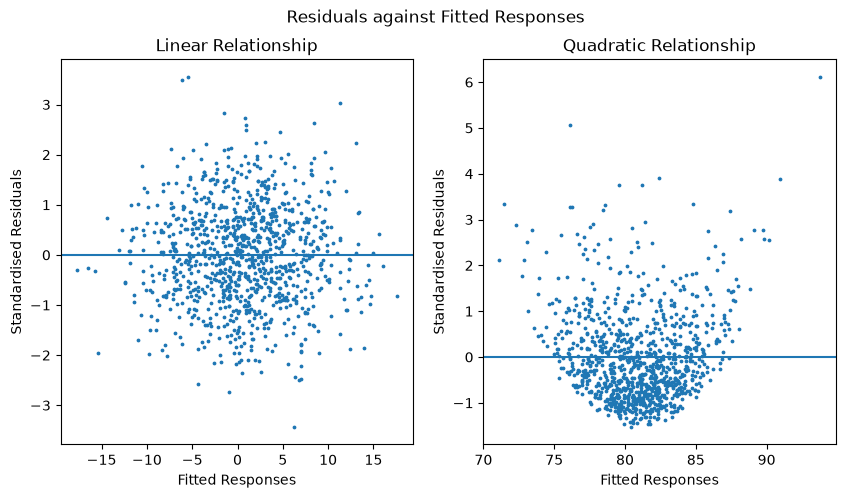

In [115]:
N = 1000
P = 5

rng = np.random.default_rng(seed=10)
X_fixed = rng.normal(0, 4, (N, P))
X_fixed = np.hstack((X_fixed, np.ones((N, 1))))
beta = rng.random(P + 1)
y1 = X_fixed @ beta + rng.normal(0, 2, N)
y2 = np.array([(X_fixed @ X_fixed.T)[i,i] for i in range(N)]) + X_fixed @ beta + rng.normal(0, 2, N)

OLS_model_1 = sm.OLS(y1, X_fixed)
OLS_model_1_fitted = OLS_model_1.fit()

standardised_residuals_1 = OLS_model_1_fitted.get_influence().resid_studentized_internal
fitted_responses_1 = OLS_model_1_fitted.predict()

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

fig.suptitle('Residuals against Fitted Responses')

axes[0].scatter(fitted_responses_1, standardised_residuals_1, s=3)
axes[0].axhline(y=0)
axes[0].set_xlabel('Fitted Responses')
axes[0].set_ylabel('Standardised Residuals')
axes[0].set_title('Linear Relationship')

OLS_model_2 = sm.OLS(y2, X_fixed)
OLS_model_2_fitted = OLS_model_2.fit()

standardised_residuals_2 = OLS_model_2_fitted.get_influence().resid_studentized_internal
fitted_responses_2 = OLS_model_2_fitted.predict()

axes[1].scatter(fitted_responses_2, standardised_residuals_2, s=3)
axes[1].axhline(y=0)
axes[1].set_xlabel('Fitted Responses')
axes[1].set_ylabel('Standardised Residuals')
axes[1].set_title('Quadratic Relationship');


Assuming the relationship is linear, to check whether the errors are normally distributed, we can look at the sizes of the standardised residuals. Arranging them from smallest to largest, the value of the $i$-th smallest term should be roughly the $\frac{1}{2}(\frac{i-1}{n} + \frac{i}{n}) \times 100$-th percentile of the normal distribution $\text{N}(0, \sigma^2)$. Plotting the sorted standardised residuals against the theoretical quantiles $\Phi^{-1}(\frac{i-0.5}{n})$, we should expect a diagonal straight line at $45$ degrees. If we see an S shape, it means that our extreme errors tend to be larger than extreme values of a normal distribution, indicating an error distribution with heavier tails. An inverted S shape would tell the opposite story.

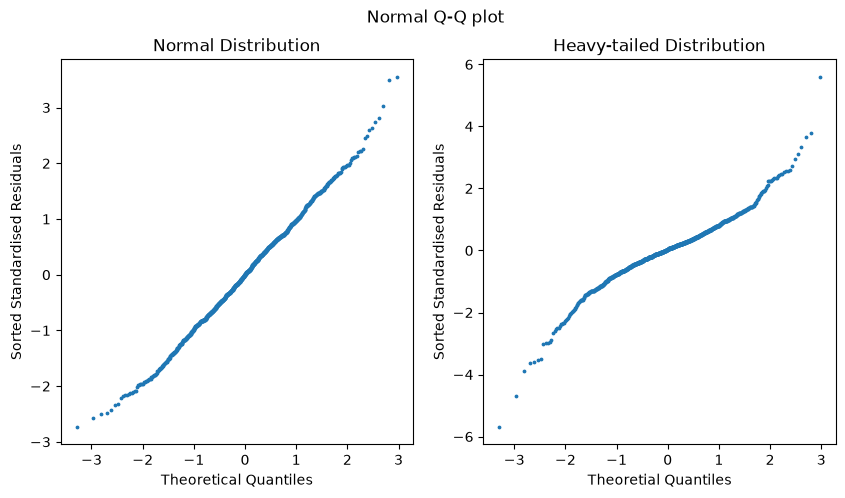

In [116]:
import pandas as pd
from scipy.special import erfinv
import math

y_t = X_fixed @ beta + 2 * np.random.standard_t(df=3, size=N)

OLS_model_t = sm.OLS(y_t, X_fixed)
OLS_model_t_fitted = OLS_model_t.fit()

standardised_residuals_t = OLS_model_t_fitted.get_influence().resid_studentized_internal
sorted_residuals_t = pd.Series(standardised_residuals_t).sort_values(ascending=True)

sorted_residuals_1 = pd.Series(standardised_residuals_1).sort_values(ascending=True)

theoretical_quantiles = [math.sqrt(2) * erfinv(2 * ((i - 0.5)/N) - 1) for i in range(N)]

fig_qq, axes_qq = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
fig_qq.suptitle('Normal Q-Q plot')

axes_qq[0].scatter(theoretical_quantiles, sorted_residuals_1, s=3)
axes_qq[0].set_xlabel('Theoretical Quantiles')
axes_qq[0].set_ylabel('Sorted Standardised Residuals')
axes_qq[0].set_title('Normal Distribution')

axes_qq[1].scatter(theoretical_quantiles, sorted_residuals_t, s=3)
axes_qq[1].set_xlabel('Theoretial Quantiles')
axes_qq[1].set_ylabel('Sorted Standardised Residuals')
axes_qq[1].set_title('Heavy-tailed Distribution');

Assuming that the errors are also normally distributed, we now check whether they are identically distributed with the same variance. The plot is similar to the residuals against fitted responses plot, just that we take the square root of the absolute standardised residuals. An increasing (or decreasing) trend indicates growing (or shrinking) variance as fitted response grows, whereas a flat trend indicates roughly constant variance.

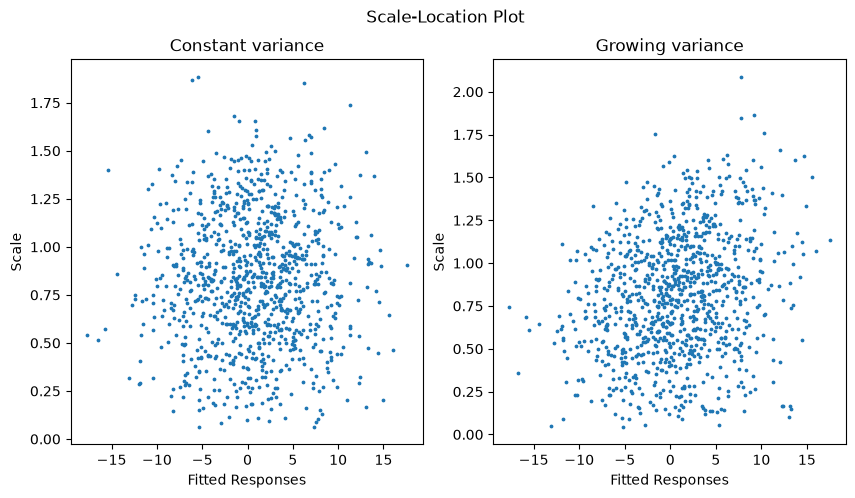

In [133]:
y_hetero = X_fixed @ beta + (X_fixed @ beta + 30) * rng.normal(0, 0.005, N)

OLS_model_hetero = sm.OLS(y_hetero, X_fixed)
OLS_model_hetero_fitted = OLS_model_hetero.fit()

scale_hetero = np.sqrt(np.abs(OLS_model_hetero_fitted.get_influence().resid_studentized_internal))
fitted_responses_hetero = OLS_model_hetero_fitted.predict()

scale_1 = np.sqrt(np.abs(standardised_residuals_1))

fig_scaleloc, axes_scaleloc = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
fig_scaleloc.suptitle('Scale-Location Plot')

axes_scaleloc[0].scatter(fitted_responses_1, scale_1, s=3)
axes_scaleloc[1].scatter(fitted_responses_hetero, scale_hetero, s=3)

for i in range(2):
    axes_scaleloc[i].set_xlabel('Fitted Responses')
    axes_scaleloc[i].set_ylabel('Scale')

axes_scaleloc[0].set_title('Constant variance')
axes_scaleloc[1].set_title('Growing variance');

Finally, to check for the presence of data points that significantly skew the fitted model, we plot a scatter plot of the residual and leverage of each data point.

What is considered a high leverage? We can see that the total leverage of all $n$ data points is just the trace of the hat matrix, which equals

$$\text{trace}(\mathbf{H}) = \text{trace}(\mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T) = \text{trace}((\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{X}) = \text{trace}(\mathbf{I}_{p}) = p$$

where $p$ is the number of columns of $\mathbf{X}$. In the above calculation, we used the property $\text{trace}(\mathbf{A}\mathbf{B}) = \text{trace}(\mathbf{B}\mathbf{A})$ in the second step.

Hence, we can say that if a data point's leverage is significantly higher than the mean, which is $\frac{p}{n}$, then it is a high-leverage point. A commonly used threshold is $3$ times the mean leverage.

As for what is considered an outlier, we can standardise the residuals, then any point with standardised residual greater than $3$ or smaller than $-3$ can be considered an outlier (since it is more than $3$ standard deviations away from the predicted mean).

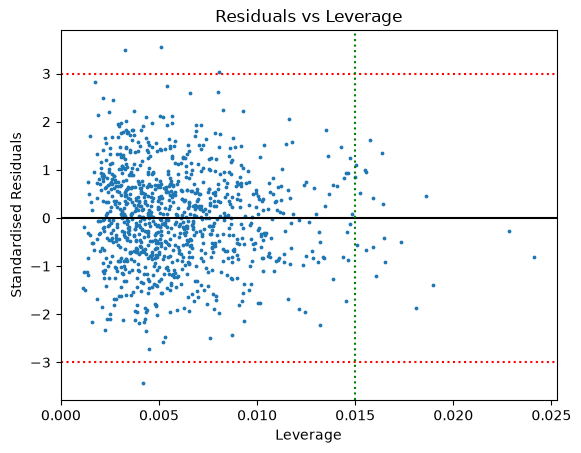

In [138]:
leverage_1 = OLS_model_1_fitted.get_influence().hat_matrix_diag

plt.scatter(leverage_1, standardised_residuals_1, s=3)
plt.axhline(y=0, color='k')
plt.axhline(y=3, color='r', ls=':')
plt.axhline(y=-3, color='r', ls=':')
plt.axvline(x=3 * P / N, color='g', ls=':')
plt.xlabel('Leverage')
plt.ylabel('Standardised Residuals')
plt.title('Residuals vs Leverage');